# Import libraries

In [1]:
import sys
github_repo_url = "https://github.com/AnnaEls/HAADF-STEM-image-denoising.git"
!git clone {github_repo_url}
sys.path.append('/content/HAADF-STEM-image-denoising')

Cloning into 'HAADF-STEM-image-denoising'...
remote: Enumerating objects: 584, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 584 (delta 76), reused 0 (delta 0), pack-reused 404 (from 2)
Receiving objects: 100% (584/584), 198.68 KiB | 5.23 MiB/s, done.
Resolving deltas: 100% (178/178), done.


In [2]:
import os
import pandas as pd
from Models.hybrid_model import hybrid_model
from Models.UNet import init_unet_kaiming
from Utilities.Utils import prepare_input, convert
from Training.Training import train_hybrid_model, train_model
from Metrics.Metrics import calculate_metrics_for_hybrid_model, fourier_entropy
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
from Training.Masking import random_patch_mask

# Settting parameters

In [7]:
#PARAMETERS
#Type of study
STUDY = 'DEFAULT_PARAMETERS'
#Image parameters
DOSE = 250000.0 #25000 - 1000000 - meaningful range of doses
#Model parameters
WIDTH = 'DEFAULT'
DEPTH = 'DEFAULT'
DEPTH_CNN = 'DEFAULT'
MODEL = hybrid_model()
init_unet_kaiming(MODEL)
#Masking parameters
PATCH_SIZE = 7
MASK_RATIO = 0.2
#Training parameters
LR = 1e-3
NUM_EPOCHS = 300
NUM_RUNS = 1

In [8]:
dataset_path = '/content/drive/MyDrive/IMAGE DENOISING/Datasets/DATASET_graphene_vacancies/'
os.makedirs(dataset_path, exist_ok=True)

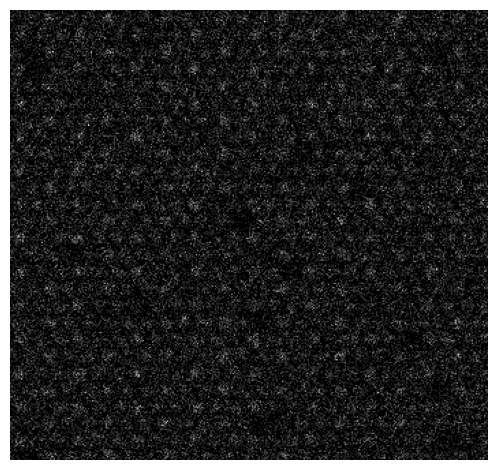

In [9]:
path_to_clean_image = dataset_path + 'graphene-ground_truth_interp_0.1_dose_no_noise.tif'
path_to_noisy_image = dataset_path + f'graphene-jittered_interp_0.1_dose_{DOSE}.tif'
input_image = prepare_input(path_to_noisy_image)

In [10]:
output_path_main = dataset_path + f'RESULTS/'
output_path_main = output_path_main + f'DOSE_{DOSE}/' + f'{MODEL.__class__.__name__}/' + f'{STUDY}/'

# Training

In [1]:
result_path = output_path_main
os.makedirs(result_path, exist_ok=True)
for run in range(NUM_RUNS):
    MODEL = hybrid_model()
    print(f'Starting run {run}')
    output_path = result_path + f'run_{run+3}/'
    os.makedirs(output_path, exist_ok=True)
    train_hybrid_model(MODEL, input_image, output_path, learning_rate=LR, num_iter=NUM_EPOCHS, patch_size=PATCH_SIZE, mask_ratio=MASK_RATIO, show_image=False)

# Calculating PSNRS

In [42]:
def calculate_metrics(path, path_to_clean_image, prefix = 'AFNO_', show_graphs=True):
    clean_image_raw = np.array(tifffile.imread(path_to_clean_image))
    clean_image = convert(clean_image_raw)

    psnrs = []
    iterations = []

    image_files = sorted([f for f in os.listdir(path) if f.endswith('.tif') and f.startswith(prefix)])

    if not image_files:
        print("No .tif files found in the specified directory.")
        return None, None, None, None, None # Now returns 5 Nones

    for image_file in image_files:
        iteration = int(image_file[len(prefix)+1:-4]) # Correctly parse iteration by skipping prefix length and underscore
        denoised_image = np.array(tifffile.imread(os.path.join(path, image_file)))

        current_psnr = psnr_metric(clean_image, denoised_image, data_range=255)
        psnrs.append(current_psnr)
        iterations.append(iteration)

    max_psnr = np.max(psnrs)
    best_psnr_iteration = iterations[np.argmax(psnrs)]
    np.save(os.path.join(path, f'psnrs_{prefix}.npy'), psnrs)


In [43]:
for run in range(NUM_RUNS):
    output_path = output_path_main + f'run_{run+1}/'
    calculate_metrics(output_path, path_to_clean_image, prefix = 'AFNO')
    calculate_metrics(output_path, path_to_clean_image, prefix = 'CNN')

In [44]:
psnrs_afno = np.load(output_path + 'psnrs_AFNO.npy')
psnrs_cnn = np.load(output_path + 'psnrs_CNN.npy')

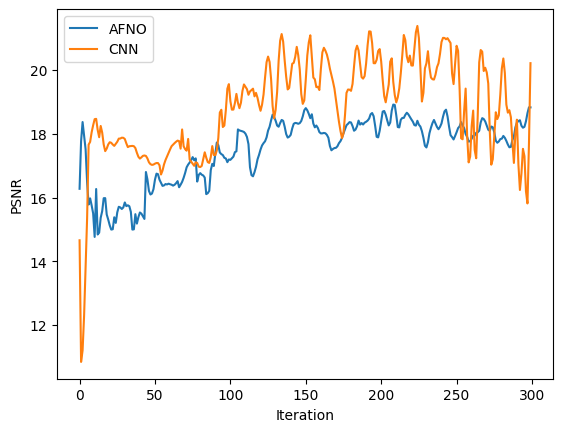

In [45]:
plt.plot(psnrs_afno, label='AFNO')
plt.plot(psnrs_cnn, label='CNN')
plt.xlabel('Iteration')
plt.ylabel('PSNR')
plt.legend()